<a href="https://colab.research.google.com/github/reddytian/dl-learning/blob/main/day3_mnist_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())

2.11.0+cu128
CUDA available: True


In [ ]:
import torch
import numpy as np

# 创建 tensor
x = torch.tensor([[1., 2.], [3., 4.]])
print(x)
print(x.shape)

# NumPy 和 torch 互转（你熟的 NumPy 直接能用）
a = np.array([1., 2., 3.])
t = torch.from_numpy(a)      # NumPy -> torch
back = t.numpy()             # torch -> NumPy
print(t, back)

# 基本运算，和 NumPy 几乎一样
print(x + 1)
print(x.sum())

tensor([[1., 2.],
        [3., 4.]])
torch.Size([2, 2])
tensor([1., 2., 3.], dtype=torch.float64) [1. 2. 3.]
tensor([[2., 3.],
        [4., 5.]])
tensor(10.)


In [ ]:
import torch

# 设 requires_grad=True，告诉 PyTorch "帮我追踪这个变量的梯度"
x = torch.tensor(3.0, requires_grad=True)

# 定义一个简单函数 y = x^2
y = x ** 2

# 反向传播：自动算 dy/dx
y.backward()

# 梯度存在 x.grad 里。 dy/dx = 2x = 2*3 = 6
print("x =", x.item())
print("y =", y.item())
print("dy/dx =", x.grad.item())   # 应该是 6.0

x = 3.0
y = 9.0
dy/dx = 6.0


Epoch   0 | loss = 16.5048
Epoch  10 | loss = 0.2183
Epoch  20 | loss = 0.1083
Epoch  30 | loss = 0.0961
Epoch  40 | loss = 0.0947
Epoch  50 | loss = 0.0945
Epoch  60 | loss = 0.0945
Epoch  70 | loss = 0.0945
Epoch  80 | loss = 0.0945
Epoch  90 | loss = 0.0945

学到的参数： w = 2.000, b = 1.011   (真值 w=2, b=1)


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38477 (\N{CJK UNIFIED IDEOGRAPH-964D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from font(s) DejaVu Sans.
  fig.canvas

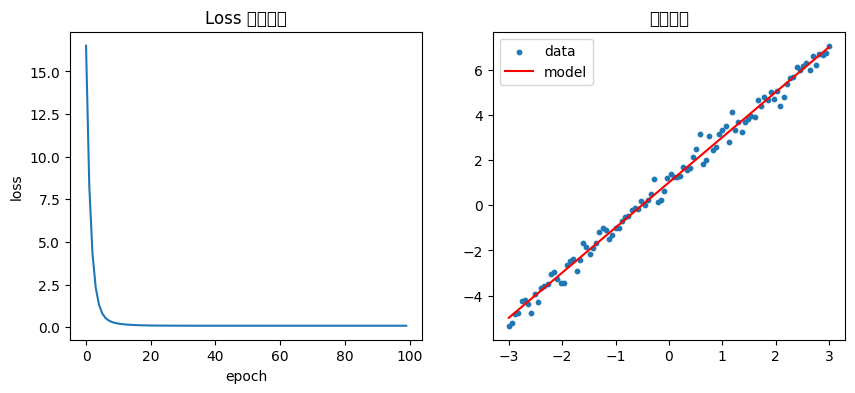

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ---------- 1. 准备数据：y = 2x + 1 (加一点噪声，模拟真实数据) ----------
torch.manual_seed(0)
x = torch.linspace(-3, 3, 100).reshape(-1, 1)   # 100 个点，形状 [100, 1]
y = 2 * x + 1 + 0.3 * torch.randn_like(x)        # 真实关系 + 噪声

# ---------- 2. 定义模型：一个线性层（就是 y = w*x + b，让它自己学 w 和 b）----------
model = nn.Linear(1, 1)    # 输入 1 维，输出 1 维

# ---------- 3. 定义 loss 和 optimizer ----------
loss_fn = nn.MSELoss()                                  # 均方误差：预测和真值差多少
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # 梯度下降，lr=学习率

# ---------- 4. 训练循环（核心！）----------
losses = []
for epoch in range(100):                 # 循环 100 遍
    # (1) 前向传播：模型做预测
    y_pred = model(x)

    # (2) 算 loss：预测和真值差多少
    loss = loss_fn(y_pred, y)

    # (3) 反向传播：autograd 自动算每个参数的梯度（就是你昨天学的 backward！）
    optimizer.zero_grad()   # (5) 先清空上一轮的梯度
    loss.backward()         # (3) 算梯度

    # (4) 更新参数：往减小 loss 的方向调一步
    optimizer.step()

    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | loss = {loss.item():.4f}")

# ---------- 5. 看结果 ----------
w, b = model.weight.item(), model.bias.item()
print(f"\n学到的参数： w = {w:.3f}, b = {b:.3f}   (真值 w=2, b=1)")

# 画 loss 曲线
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Loss 下降曲线")

# 画拟合结果
plt.subplot(1,2,2)
plt.scatter(x, y, s=10, label="data")
plt.plot(x, model(x).detach(), 'r', label="model")
plt.legend(); plt.title("拟合结果")
plt.show()


Epoch   0 | loss = 16.5048
Epoch  10 | loss = 27969616480900743168.0000
Epoch  20 | loss = inf
Epoch  30 | loss = inf
Epoch  40 | loss = inf
Epoch  50 | loss = nan
Epoch  60 | loss = nan
Epoch  70 | loss = nan
Epoch  80 | loss = nan
Epoch  90 | loss = nan

学到的参数： w = nan, b = nan   (真值 w=2, b=1)


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38477 (\N{CJK UNIFIED IDEOGRAPH-964D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from font(s) DejaVu Sans.
  fig.canvas

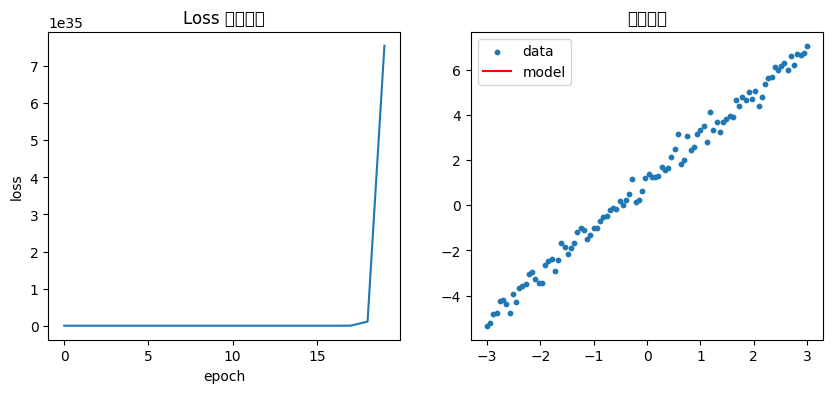

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ---------- 1. 准备数据：y = 2x + 1 (加一点噪声，模拟真实数据) ----------
torch.manual_seed(0)
x = torch.linspace(-3, 3, 100).reshape(-1, 1)   # 100 个点，形状 [100, 1]
y = 2 * x + 1 + 0.3 * torch.randn_like(x)        # 真实关系 + 噪声

# ---------- 2. 定义模型：一个线性层（就是 y = w*x + b，让它自己学 w 和 b）----------
model = nn.Linear(1, 1)    # 输入 1 维，输出 1 维

# ---------- 3. 定义 loss 和 optimizer ----------
loss_fn = nn.MSELoss()                                  # 均方误差：预测和真值差多少
optimizer = torch.optim.SGD(model.parameters(), lr=1.5)  # 梯度下降，lr=学习率

# ---------- 4. 训练循环（核心！）----------
losses = []
for epoch in range(100):                 # 循环 100 遍
    # (1) 前向传播：模型做预测
    y_pred = model(x)

    # (2) 算 loss：预测和真值差多少
    loss = loss_fn(y_pred, y)

    # (3) 反向传播：autograd 自动算每个参数的梯度（就是你昨天学的 backward！）
    optimizer.zero_grad()   # (5) 先清空上一轮的梯度
    loss.backward()         # (3) 算梯度

    # (4) 更新参数：往减小 loss 的方向调一步
    optimizer.step()

    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | loss = {loss.item():.4f}")

# ---------- 5. 看结果 ----------
w, b = model.weight.item(), model.bias.item()
print(f"\n学到的参数： w = {w:.3f}, b = {b:.3f}   (真值 w=2, b=1)")

# 画 loss 曲线
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Loss 下降曲线")

# 画拟合结果
plt.subplot(1,2,2)
plt.scatter(x, y, s=10, label="data")
plt.plot(x, model(x).detach(), 'r', label="model")
plt.legend(); plt.title("拟合结果")
plt.show()

Epoch   0 | loss = 16.6504
Epoch  10 | loss = 8.4144
Epoch  20 | loss = 7.4360
Epoch  30 | loss = 7.3170
Epoch  40 | loss = 7.3026
Epoch  50 | loss = 7.3008
Epoch  60 | loss = 7.3006
Epoch  70 | loss = 7.3006
Epoch  80 | loss = 7.3006
Epoch  90 | loss = 7.3006

学到的参数： w = -0.000, b = 3.072   (真值 w=2, b=1)


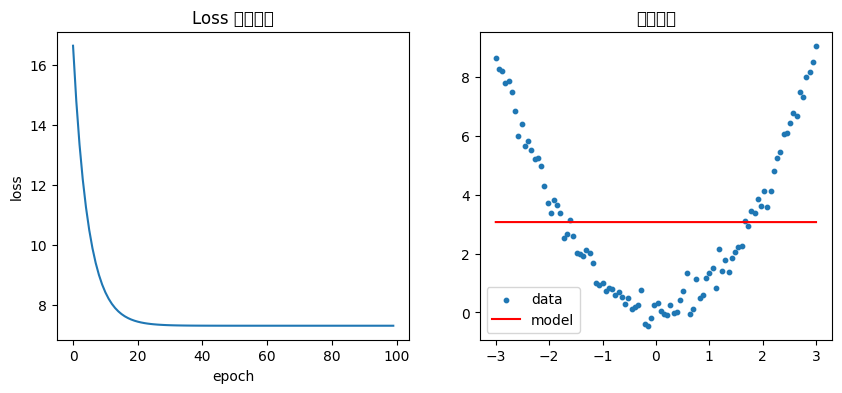

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ---------- 1. 准备数据：y = 2x + 1 (加一点噪声，模拟真实数据) ----------
torch.manual_seed(0)
x = torch.linspace(-3, 3, 100).reshape(-1, 1)   # 100 个点，形状 [100, 1]
y = x**2 + 0.3 * torch.randn_like(x)    # 真实关系是曲线 y = x²

# ---------- 2. 定义模型：一个线性层（就是 y = w*x + b，让它自己学 w 和 b）----------
model = nn.Linear(1, 1)    # 输入 1 维，输出 1 维

# ---------- 3. 定义 loss 和 optimizer ----------
loss_fn = nn.MSELoss()                                  # 均方误差：预测和真值差多少
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # 梯度下降，lr=学习率

# ---------- 4. 训练循环（核心！）----------
losses = []
for epoch in range(100):                 # 循环 100 遍
    # (1) 前向传播：模型做预测
    y_pred = model(x)

    # (2) 算 loss：预测和真值差多少
    loss = loss_fn(y_pred, y)

    # (3) 反向传播：autograd 自动算每个参数的梯度（就是你昨天学的 backward！）
    optimizer.zero_grad()   # (5) 先清空上一轮的梯度
    loss.backward()         # (3) 算梯度

    # (4) 更新参数：往减小 loss 的方向调一步
    optimizer.step()

    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | loss = {loss.item():.4f}")

# ---------- 5. 看结果 ----------
w, b = model.weight.item(), model.bias.item()
print(f"\n学到的参数： w = {w:.3f}, b = {b:.3f}   (真值 w=2, b=1)")

# 画 loss 曲线
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Loss 下降曲线")

# 画拟合结果
plt.subplot(1,2,2)
plt.scatter(x, y, s=10, label="data")
plt.plot(x, model(x).detach(), 'r', label="model")
plt.legend(); plt.title("拟合结果")
plt.show()

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 495kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.55MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


训练集: 60000 张, 测试集: 10000 张
一个 batch 的形状: torch.Size([64, 1, 28, 28])


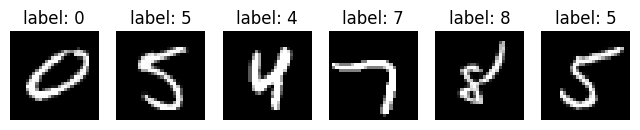

In [4]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 数据预处理：转成 tensor
transform = transforms.ToTensor()

# 下载 MNIST（手写数字 0-9，28x28 灰度图）
train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader：把数据分成小批次(batch)喂给模型
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=1000)

print(f"训练集: {len(train_data)} 张, 测试集: {len(test_data)} 张")

# 看几张图长啥样
images, labels = next(iter(train_loader))
print("一个 batch 的形状:", images.shape)   # [64, 1, 28, 28]
plt.figure(figsize=(8,2))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f"label: {labels[i].item()}")
    plt.axis('off')
plt.show()

In [5]:
# 一个简单的神经网络：784 输入 -> 128 隐藏 -> 10 输出(对应0-9)
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()          # 把 28x28 图片拉平成 784 的向量
        self.fc1 = nn.Linear(28*28, 128)     # 第一层
        self.relu = nn.ReLU()                # 非线性激活！(昨天缺的就是这个)
        self.fc2 = nn.Linear(128, 10)        # 输出层：10 个数字的分数

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))           # 线性 -> ReLU 非线性
        x = self.fc2(x)
        return x

# 用 GPU（如果开了）
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Net().to(device)
print(model)
print("使用设备:", device)

Net(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
使用设备: cuda


Epoch 1 | train loss = 0.3438
Epoch 2 | train loss = 0.1632
Epoch 3 | train loss = 0.1128
Epoch 4 | train loss = 0.0840
Epoch 5 | train loss = 0.0662


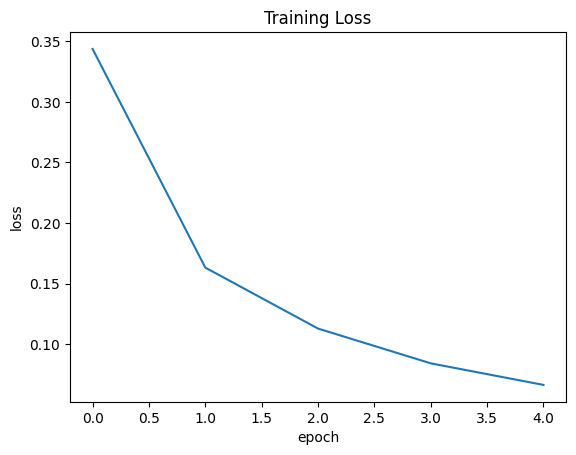

In [6]:
loss_fn = nn.CrossEntropyLoss()   # 分类任务用交叉熵 loss(昨天回归用 MSE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # Adam：比 SGD 更聪明的优化器

train_losses = []
for epoch in range(5):        # 训练 5 轮
    model.train()
    running_loss = 0
    for images, labels in train_loader:      # 遍历每个 batch
        images, labels = images.to(device), labels.to(device)

        # ===== 昨天学的 5 步，一模一样 =====
        y_pred = model(images)               # 1 前向
        loss = loss_fn(y_pred, labels)       # 2 loss
        optimizer.zero_grad()                # 5 清梯度
        loss.backward()                      # 3 反向
        optimizer.step()                     # 4 更新
        # ================================

        running_loss += loss.item()

    avg = running_loss / len(train_loader)
    train_losses.append(avg)
    print(f"Epoch {epoch+1} | train loss = {avg:.4f}")

plt.plot(train_losses); plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Training Loss"); plt.show()

测试集准确率: 97.46%



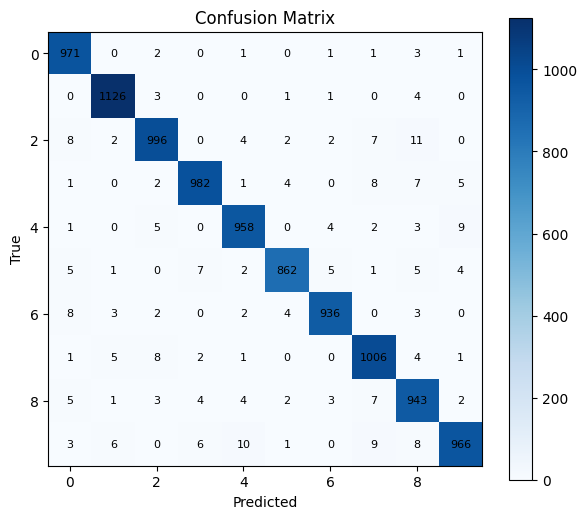

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.98      0.97      0.98      1010
           4       0.97      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.97      1028
           8       0.95      0.97      0.96       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

model.eval()                          # 切换到评估模式
all_preds, all_labels = [], []
with torch.no_grad():                 # 评估时不需要算梯度
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()   # 取分数最高的那个数字
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"测试集准确率: {acc*100:.2f}%\n")

# 混淆矩阵(你熟的)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar(); plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i,j], ha='center', va='center', fontsize=8)
plt.show()

print(classification_report(all_labels, all_preds))

In [8]:
def evaluate(loader, name):
    model.eval()
    preds, labels_all = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            out = model(images)
            preds.extend(out.argmax(1).cpu().numpy())
            labels_all.extend(labels.numpy())
    from sklearn.metrics import accuracy_score
    acc = accuracy_score(labels_all, preds)
    print(f"{name} 准确率: {acc*100:.2f}%")
    return acc

# 同时看训练集和测试集
train_acc = evaluate(train_loader, "训练集")
test_acc  = evaluate(test_loader,  "测试集")
print(f"\n差距(train - test): {(train_acc-test_acc)*100:.2f}%")

训练集 准确率: 98.58%
测试集 准确率: 97.46%

差距(train - test): 1.12%
